# Multiple Regression and Interaction: Predicting Spotify Streams

**Research Question (RQ2):** After controlling for user demographics and listening behavior, do accounts classified as bot-like show significantly higher stream counts than human accounts, and does bot-like status moderate the relationship between listening time and total streams?

**Hypotheses:**
- **H2:** Bot-like accounts have significantly higher mean stream counts than human accounts, controlling for listening time and age ($\beta > 0$, $p < .05$).
- **H2a (Interaction):** The marginal effect of listening time on streams is greater for bot-like accounts than for humans ($\beta_{\text{interaction}} > 0$, $p < .05$).

This notebook covers:
1. Data preparation and variable setup
2. Baseline multiple regression with VIF check
3. Interaction model (listening_time centered $\times$ bot_like)
4. Residual diagnostics (linearity, homoscedasticity, normality)
5. Model comparison by AIC / BIC / adjusted $R^2$
6. Simple-slopes interaction plot

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

from src.data_loader import create_dummies

%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#1DB954", "#B3B3B3"]

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv(os.path.join("..", "data", "cleaned", "spotify_clean_v1.csv"))
df_model = create_dummies(df, columns=["fav_music_genre"])
genre_dummies = [c for c in df_model.columns if c.startswith("fav_music_genre_")]

print(f"Dataset: {df_model.shape[0]} rows x {df_model.shape[1]} cols")
print(f"Genre dummies: {genre_dummies}")

Dataset: 520 rows x 33 cols
Genre dummies: ['fav_music_genre_Electronic/Dance', 'fav_music_genre_Melody', 'fav_music_genre_Pop', 'fav_music_genre_Rap', 'fav_music_genre_Rock']


In [3]:
# Mean-center listening_time to reduce collinearity with the interaction term
lt_mean = df_model["listening_time"].mean()
df_model["lt_c"] = df_model["listening_time"] - lt_mean
df_model["lt_c_x_bot"] = df_model["lt_c"] * df_model["bot_like"]

print(f"Centered listening_time mean (should be ~0): {df_model['lt_c'].mean():.2e}")
print(f"Original mean used for centering: {lt_mean:.2f} min/day")

Centered listening_time mean (should be ~0): -3.56e-14
Original mean used for centering: 146.98 min/day


## 3. Baseline Multiple Regression (Model A)

Predict streams from listening time, bot-like status, age, skip rate, diversity, and genre dummies — no interaction yet.

In [4]:
base_preds = ["listening_time", "bot_like", "age_numeric", "skip_rate", "diversity_score"] + genre_dummies
Xa = sm.add_constant(df_model[base_preds])
y  = df_model["streams"]

model_a = sm.OLS(y, Xa).fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     32.56
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           9.48e-49
Time:                        18:50:16   Log-Likelihood:                -3945.9
No. Observations:                 520   AIC:                             7914.
Df Residuals:                     509   BIC:                             7961.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### 3.1 Multicollinearity (VIF)

VIF > 5 signals concerning collinearity; VIF > 10 is problematic.

In [5]:
vif_rows = []
for i, col in enumerate(Xa.columns):
    if col == "const":
        continue
    vif_rows.append({"Variable": col, "VIF": variance_inflation_factor(Xa.values, i)})
vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
print("VIFs for baseline model:")
print(vif_df.round(3).to_string(index=False))

VIFs for baseline model:
                        Variable   VIF
          fav_music_genre_Melody 2.263
                  listening_time 2.073
             fav_music_genre_Pop 1.924
                 diversity_score 1.832
             fav_music_genre_Rap 1.464
                       skip_rate 1.425
                        bot_like 1.396
fav_music_genre_Electronic/Dance 1.204
            fav_music_genre_Rock 1.054
                     age_numeric 1.052


## 4. Interaction Model (Model B)

Test whether bot-like status moderates the listening-time $\rightarrow$ streams slope. Use centered listening time so the main effect represents the slope at the sample mean.

In [6]:
int_preds = ["lt_c", "bot_like", "lt_c_x_bot", "age_numeric", "skip_rate", "diversity_score"] + genre_dummies
Xb = sm.add_constant(df_model[int_preds])

model_b = sm.OLS(y, Xb).fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     30.07
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.00e-48
Time:                        18:50:16   Log-Likelihood:                -3944.1
No. Observations:                 520   AIC:                             7912.
Df Residuals:                     508   BIC:                             7963.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

In [7]:
# VIF for interaction model (centering should keep lt_c and lt_c_x_bot well below 5)
vif_rows = []
for i, col in enumerate(Xb.columns):
    if col == "const":
        continue
    vif_rows.append({"Variable": col, "VIF": variance_inflation_factor(Xb.values, i)})
vif_df_b = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False).reset_index(drop=True)
print("VIFs for interaction model:")
print(vif_df_b.round(3).to_string(index=False))

VIFs for interaction model:
                        Variable   VIF
          fav_music_genre_Melody 2.273
                            lt_c 2.250
             fav_music_genre_Pop 1.930
                 diversity_score 1.847
                        bot_like 1.586
             fav_music_genre_Rap 1.464
                       skip_rate 1.430
                      lt_c_x_bot 1.361
fav_music_genre_Electronic/Dance 1.211
            fav_music_genre_Rock 1.063
                     age_numeric 1.052


## 5. Residual Diagnostics

Check the OLS assumptions on the interaction model (Model B):
- **Linearity:** residuals vs. fitted should show no systematic pattern.
- **Homoscedasticity:** residual spread should be roughly constant (Breusch–Pagan).
- **Normality:** residuals should look approximately normal (QQ plot + Shapiro–Wilk).

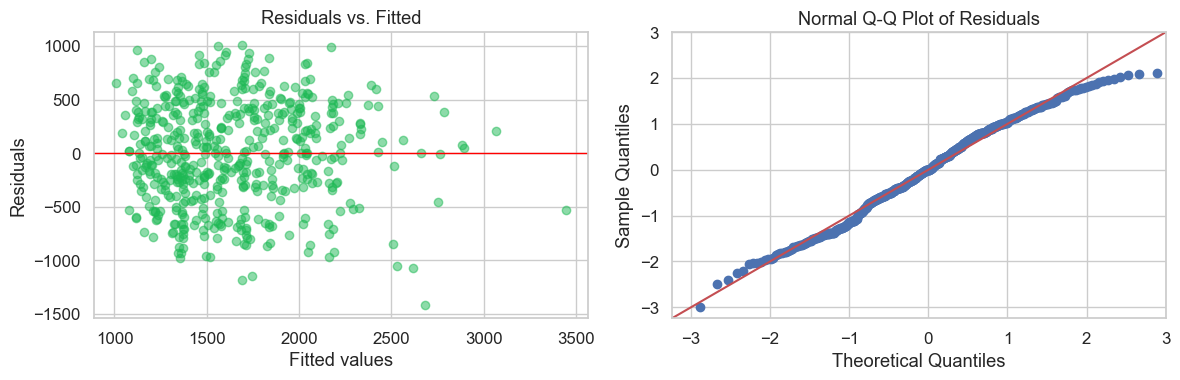

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs fitted
axes[0].scatter(model_b.fittedvalues, model_b.resid, alpha=0.5, color=PALETTE[0])
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

# QQ plot
sm.qqplot(model_b.resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [9]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(model_b.resid, model_b.model.exog)
print(f"Breusch-Pagan: LM = {bp[0]:.2f}, p = {bp[1]:.4f}")

sw_stat, sw_p = stats.shapiro(model_b.resid)
print(f"Shapiro-Wilk:  W  = {sw_stat:.3f}, p = {sw_p:.4f}")

Breusch-Pagan: LM = 28.44, p = 0.0028
Shapiro-Wilk:  W  = 0.987, p = 0.0002


## 6. Model Comparison (AIC / BIC / Adjusted R²)

Compare the baseline model against the interaction model to decide whether the interaction is worth the extra parameter.

In [10]:
comparison = pd.DataFrame({
    "Model": ["A: Baseline", "B: Interaction"],
    "k": [len(base_preds), len(int_preds)],
    "R2": [model_a.rsquared, model_b.rsquared],
    "Adj R2": [model_a.rsquared_adj, model_b.rsquared_adj],
    "AIC": [model_a.aic, model_b.aic],
    "BIC": [model_a.bic, model_b.bic],
}).round(3)
print("Model comparison:")
print(comparison.to_string(index=False))

# Partial F-test on the interaction term alone
from statsmodels.stats.anova import anova_lm
# Refit baseline with centered lt so nested comparison is valid
Xa_c = sm.add_constant(df_model[["lt_c", "bot_like", "age_numeric", "skip_rate", "diversity_score"] + genre_dummies])
model_a_c = sm.OLS(y, Xa_c).fit()
print("\nNested F-test (baseline vs + interaction):")
print(anova_lm(model_a_c, model_b))

Model comparison:
         Model  k    R2  Adj R2      AIC      BIC
   A: Baseline 10 0.390   0.378 7913.755 7960.547
B: Interaction 11 0.394   0.381 7912.151 7963.196

Nested F-test (baseline vs + interaction):
   df_resid           ssr  df_diff        ss_diff        F    Pr(>F)
0     509.0  1.187348e+08      0.0            NaN      NaN       NaN
1     508.0  1.179147e+08      1.0  820098.938288  3.53315  0.060726


## 7. Simple-Slopes Interaction Plot

Plot predicted streams as a function of listening time, separately for bot-like and human accounts, holding other predictors at their sample means. Steeper slope for the bot-like line would support **H2a**.

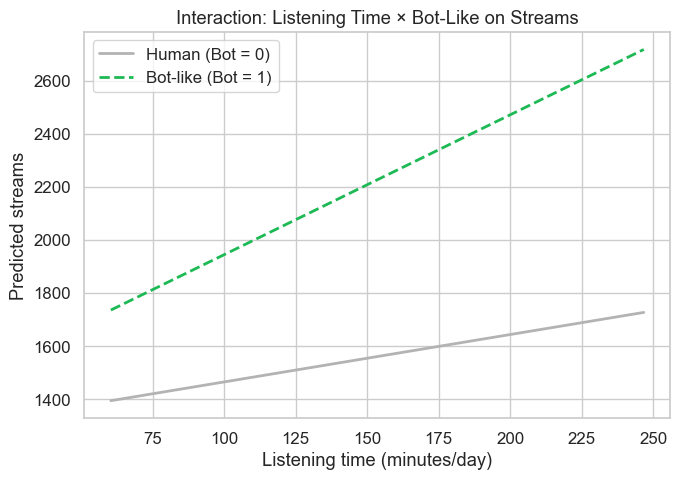

In [11]:
# Build a grid of listening-time values
lt_grid = np.linspace(df_model["listening_time"].min(), df_model["listening_time"].max(), 50)
lt_c_grid = lt_grid - lt_mean

# Hold covariates at their sample means
age_m   = df_model["age_numeric"].mean()
skip_m  = df_model["skip_rate"].mean()
div_m   = df_model["diversity_score"].mean()
genre_m = df_model[genre_dummies].mean()

def predict_line(bot_status):
    rows = []
    for lt_c in lt_c_grid:
        row = {"const": 1.0,
               "lt_c": lt_c,
               "bot_like": bot_status,
               "lt_c_x_bot": lt_c * bot_status,
               "age_numeric": age_m,
               "skip_rate": skip_m,
               "diversity_score": div_m}
        for g in genre_dummies:
            row[g] = genre_m[g]
        rows.append(row)
    Xgrid = pd.DataFrame(rows)[Xb.columns]
    return model_b.predict(Xgrid)

pred_human = predict_line(0)
pred_bot   = predict_line(1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lt_grid, pred_human, linewidth=2, color=PALETTE[1], label="Human (Bot = 0)")
ax.plot(lt_grid, pred_bot,   linewidth=2, color=PALETTE[0], linestyle="--", label="Bot-like (Bot = 1)")
ax.set_xlabel("Listening time (minutes/day)")
ax.set_ylabel("Predicted streams")
ax.set_title("Interaction: Listening Time × Bot-Like on Streams")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hypothesis Verdicts

- **H2 (bot-like $\rightarrow$ more streams):** supported if the `bot_like` coefficient is positive and $p < .05$ in Model B.
- **H2a (positive interaction):** supported if `lt_c_x_bot` coefficient is positive and $p < .05$; marginal support if $.05 \le p < .10$.

The final directional verdicts are carried forward into the Discussion section of the paper.